In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

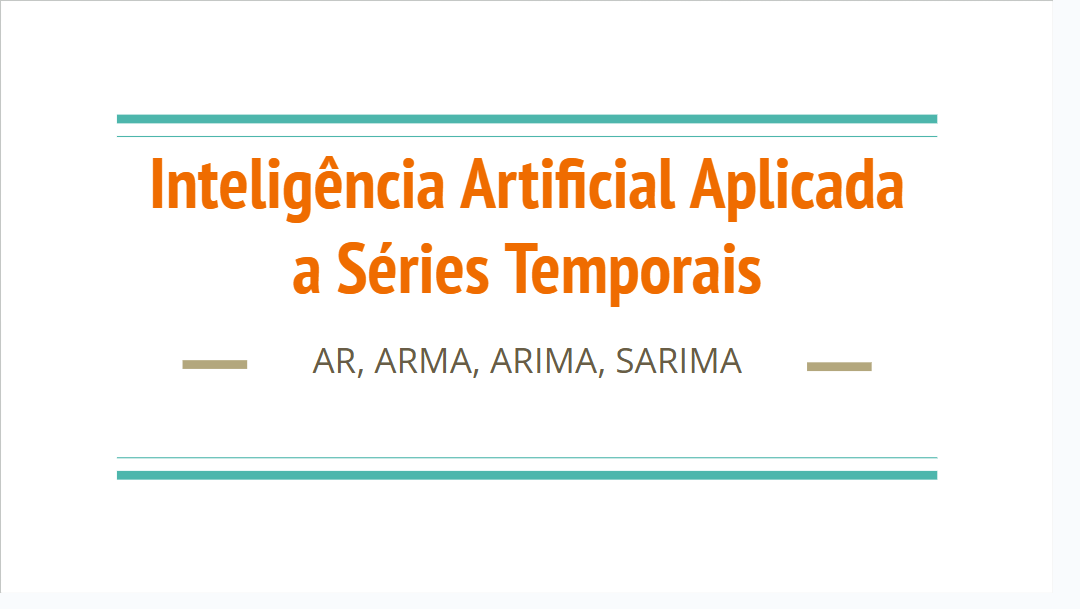

## Dataset

Este é um conjunto de dados de produção de leite de uma fábrica. Ele mostra a produção entre 1962 e 1975.

In [ ]:
# carrega dados em um dataframe pandas
df = pd.read_csv('monthly-milk-production-pounds.csv')

# Renomear colunas para facilitar o acesso
df.columns = ['Month', 'Production']

df

,Month,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [ ]:
# Converter a coluna 'Month' para o tipo datetime e definir como índice
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

Vamos tentar prever a produção para os anos de 1974 e 1975

In [ ]:
# Filtrar o conjunto de treinamento para os anos de 1973 a 1975
test_df = df['1974-01':'1975-12']
train_df = df.drop(test_df.index)  # Dados fora do período de treino

print('Observações treino:', len(train_df))
print('Observações teste:', len(test_df))

# Definindo frequência mensal para os modelos ARMA, ARIMA, SARIMA
df = df.asfreq('MS')

Observações treino: 144
Observações teste: 24


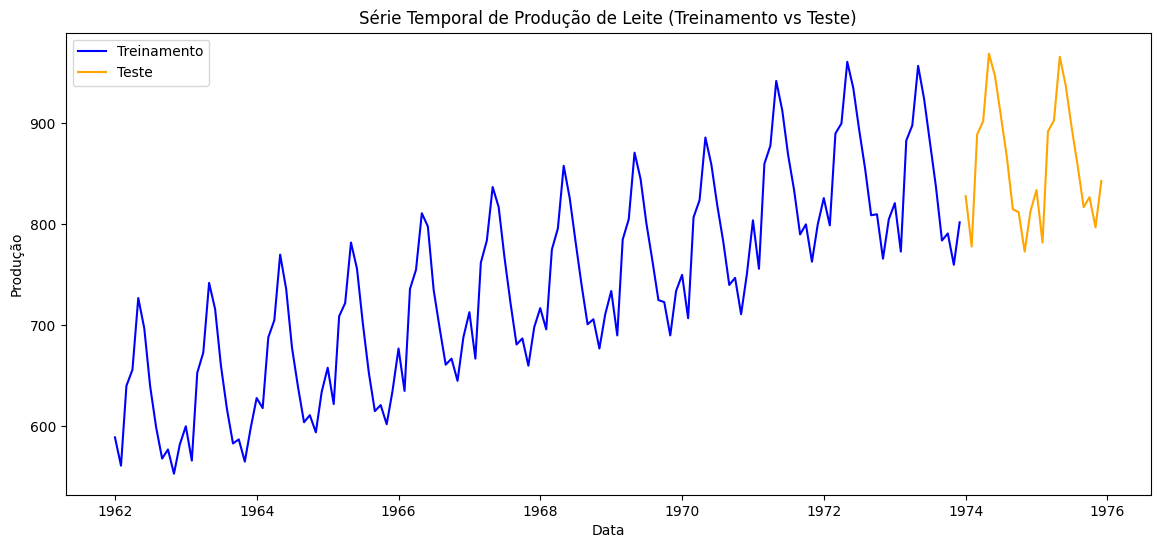

In [ ]:
# Plotar a série temporal com destaque para as partes de treinamento e teste
plt.figure(figsize=(14, 6))
plt.plot(train_df.index, train_df['Production'], label='Treinamento', color='blue')
plt.plot(test_df.index, test_df['Production'], label='Teste', color='orange')
plt.xlabel('Data')
plt.ylabel('Produção')
plt.title('Série Temporal de Produção de Leite (Treinamento vs Teste)')
plt.legend()

Como métrica para estimar o desempenho dos modelos, vamos utilizar o **Erro Quadrático Médio**.

### Baselines

#### Base

In [ ]:
# Modelo base
def basemodel(series):
  N = len(series)
  y = series.copy()

  for t in range(1, N):
    y.iloc[t] = series.iloc[t-1]

  return y

In [ ]:
# Aplicar o modelo base no conjunto de teste
y_pred_base = basemodel(test_df['Production'])

# Calcular o Erro Quadrático Médio
mse_base = mean_squared_error(test_df['Production'], y_pred_base)

print(f'Erro quadrático médio do modelo base: {int(mse_base)}')

Erro quadrático médio do modelo base: 2379


#### Tendência

In [ ]:
def trend_model(series,m):
  N = len(series)
  y = series.copy()
  for t in range(1, N):
    y.iloc[t] = series.iloc[t-1] + (series.iloc[t-1] - series.iloc[t-m])/(m-1)
  return y

In [ ]:
# Aplicar o modelo de tendência no conjunto de teste
y_pred_trend = trend_model(test_df['Production'], 3)

# Calcular o Erro Quadrático Médio
mse_trend = mean_squared_error(test_df['Production'], y_pred_trend)

print(f'Erro Quadrático Médio do modelo de tendência: {int(mse_trend)}')

Erro Quadrático Médio do modelo de tendência: 3153


<ipython-input-44-18adf56ed518>:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '843.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  y.iloc[t] = series.iloc[t-1] + (series.iloc[t-1] - series.iloc[t-m])/(m-1)


#### Sazonal

In [ ]:
# Função do modelo de sazonalidade
def sazonalbasemodel(series, s):
    N = len(series)
    y = series.copy()
    for t in range(s, N):
        y.iloc[t] = series.iloc[t - s]
    return y

In [ ]:
# Aplicar o modelo sazonal no conjunto de teste
s = 12  # Assumindo sazonalidade anual (dados mensais)
y_pred_sazonal = sazonalbasemodel(test_df['Production'], s)

# Calcular o Erro Quadrático Médio
mse_sazonal = mean_squared_error(test_df['Production'][s:], y_pred_sazonal[s:])  # Ignora os primeiros s valores

print(f'Erro Quadrático Médio do modelo sazonal: {mse_sazonal:.2f}')

Erro Quadrático Médio do modelo sazonal: 175.08


#### Autoregressivo

In [ ]:
# Função do modelo autoregressivo
def ar_model(series, lags):
    y_pred = series.copy()

    # Preencher os primeiros 'lags' valores com NaN
    y_pred.iloc[:lags] = np.nan

    # Calcular previsões a partir do ponto em que há dados suficientes para os lags
    for t in range(lags, len(series)):
        y_pred.iloc[t] = series.iloc[t-1] * 0.3 + series.iloc[t-2] * 0.3 + series.iloc[t-3] * 0.4

    return y_pred

In [ ]:
# Aplicar o modelo autoregressivo no conjunto de teste
y_pred_ar = ar_model(test_df['Production'], lags=3)

# Remover os valores NaN de y_pred_ar e igualar o comprimento com test_df
y_pred_ar = y_pred_ar.dropna()
y_true = test_df['Production'].iloc[-len(y_pred_ar):]  # Usa o mesmo comprimento que y_pred_ar

# Calcular o MSE
mse_ar = mean_squared_error(y_true, y_pred_ar)

print(f'Erro Quadrático Médio do modelo autoregressivo: {int(mse_ar)}')

Erro Quadrático Médio do modelo autoregressivo: 4183


Vejamos a comparação dos modelos

Text(0.5, 1.0, 'Comparação entre Modelos')

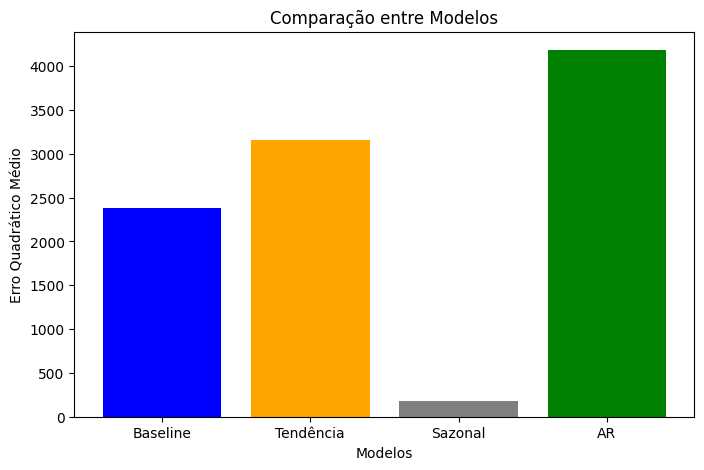

In [ ]:
# Dados para o gráfico
modelos = ['Baseline', 'Tendência', 'Sazonal', 'AR']
mse_values = [mse_base, mse_trend, mse_sazonal, mse_ar]

# Plotando o gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(modelos, mse_values, color=['blue', 'orange',  'gray', 'green'])
plt.xlabel('Modelos')
plt.ylabel('Erro Quadrático Médio')
plt.title('Comparação entre Modelos')

## Média Móvel

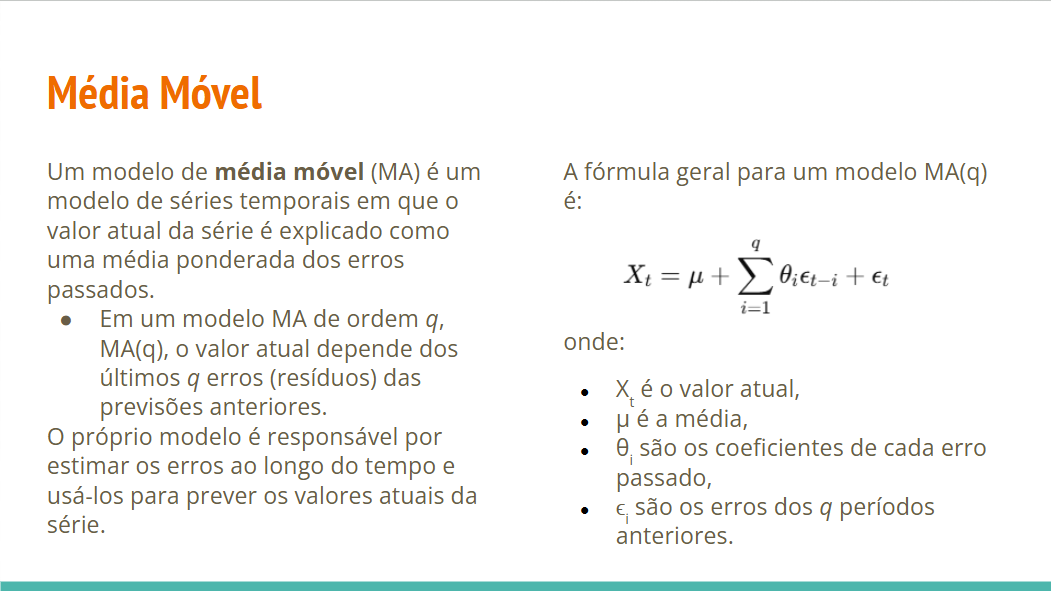

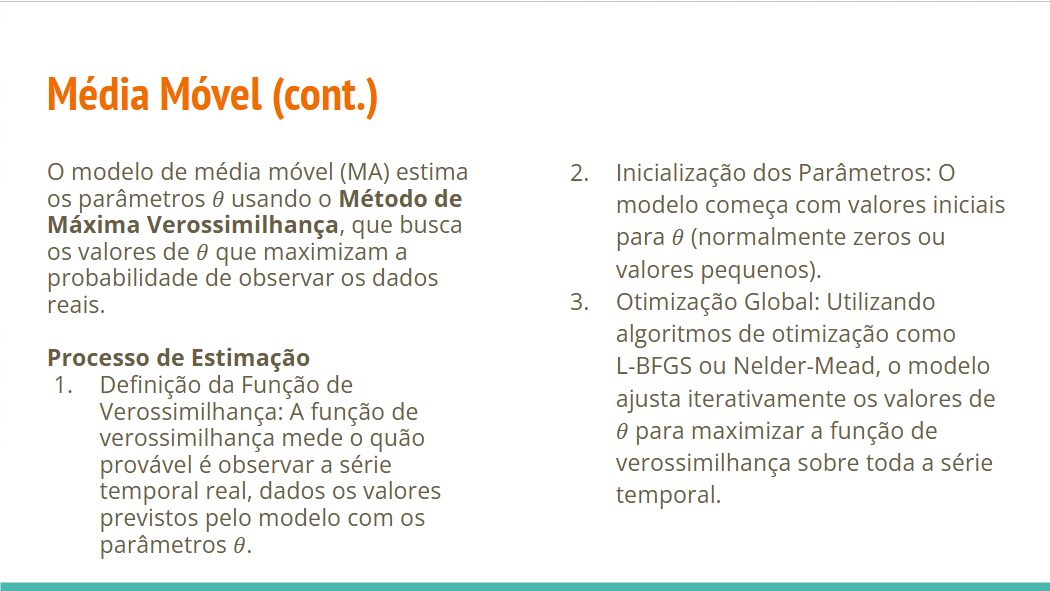

Vamos estimar um modelo de média móvel de ordem q, com q=2.

In [ ]:
# Definindo um modelo de média móvel (MA) de ordem q
ma_model = ARIMA(train_df, order=(0, 0, 2))  # p=0, d=0, q=2

# Ajustando o modelo ao conjunto de treino
ma_result = ma_model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
# Fazendo previsões no conjunto de teste
y_pred_ma = ma_result.forecast(steps=len(test_df))

# Alinhar o índice das previsões com o índice dos valores reais
y_pred_ma.index = test_df.index

# Calculando o Erro Absoluto Percentual Médio (MAPE) para o modelo MA(q)
mse_ma = mean_squared_error(test_df, y_pred_ma)

print(f'Erro Quadrático Médio do modelo de média móvel: {int(mse_ma)}')

Erro Quadrático Médio do modelo de média móvel: 18328


Text(0.5, 1.0, 'Comparação entre Modelos')

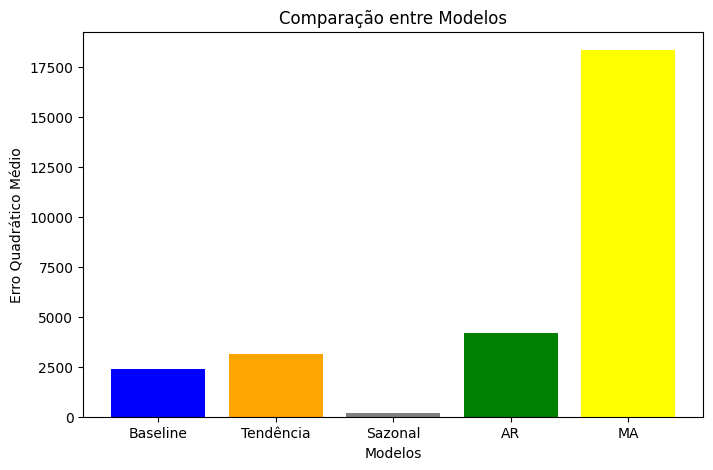

In [ ]:
# Dados para o gráfico
modelos = ['Baseline', 'Tendência', 'Sazonal', 'AR', 'MA']
mse_values = [mse_base, mse_trend, mse_sazonal, mse_ar, mse_ma]

# Plotando o gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(modelos, mse_values, color=['blue', 'orange',  'gray', 'green', 'yellow'])
plt.xlabel('Modelos')
plt.ylabel('Erro Quadrático Médio')
plt.title('Comparação entre Modelos')

## ARMA

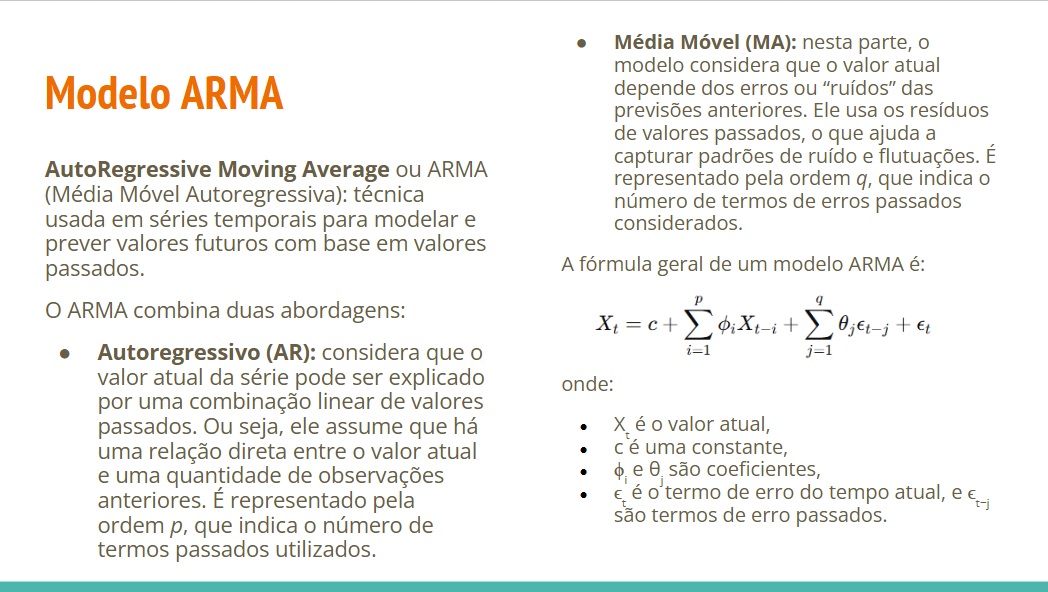

Um modelo ARMA é descrito como ARMA(p,q), em que *p* representa a ordem do componente autoregressivo (AR), ou seja, o número de valores passados da série temporal que o modelo usa para fazer a previsão atual; e *q* representa a ordem do componente de média móvel (MA), ou seja, o número de erros passados (ou resíduos) que o modelo considera para ajustar a previsão atual.

In [ ]:
# Ajustar o modelo ARMA no conjunto de treino
arma_model = ARIMA(train_df, order=(2, 0, 1))  # (p=2, d=0, q=1)

arma_result = arma_model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

In [ ]:
# Fazer previsões no conjunto de teste
y_pred_arma = arma_result.forecast(steps=len(test_df))

# Alinhar o índice das previsões com o índice dos valores reais
y_pred_arma.index = test_df.index

# Remover possíveis NaNs (caso haja alguma discrepância inicial)
y_pred_arma = y_pred_arma.dropna()
test_df = test_df.loc[y_pred_arma.index]  # Ajusta o conjunto de teste para o mesmo índice

# Calcular o MAEP
mse_arma = mean_squared_error(test_df, y_pred_arma)

print(f'Erro Quadrático Médio do modelo ARMA: {int(mse_arma)}')

Erro Quadrático Médio do modelo ARMA: 13896


Text(0.5, 1.0, 'Comparação entre Modelos')

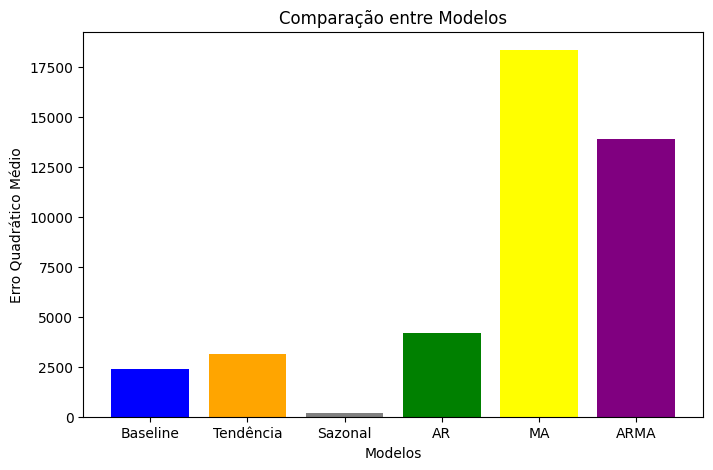

In [ ]:
# Dados para o gráfico
modelos = ['Baseline', 'Tendência', 'Sazonal', 'AR', 'MA', 'ARMA']
mse_values = [mse_base, mse_trend, mse_sazonal, mse_ar, mse_ma, mse_arma]

# Plotando o gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(modelos, mse_values, color=['blue', 'orange',  'gray', 'green', 'yellow', 'purple'])
plt.xlabel('Modelos')
plt.ylabel('Erro Quadrático Médio')
plt.title('Comparação entre Modelos')

## ARIMA

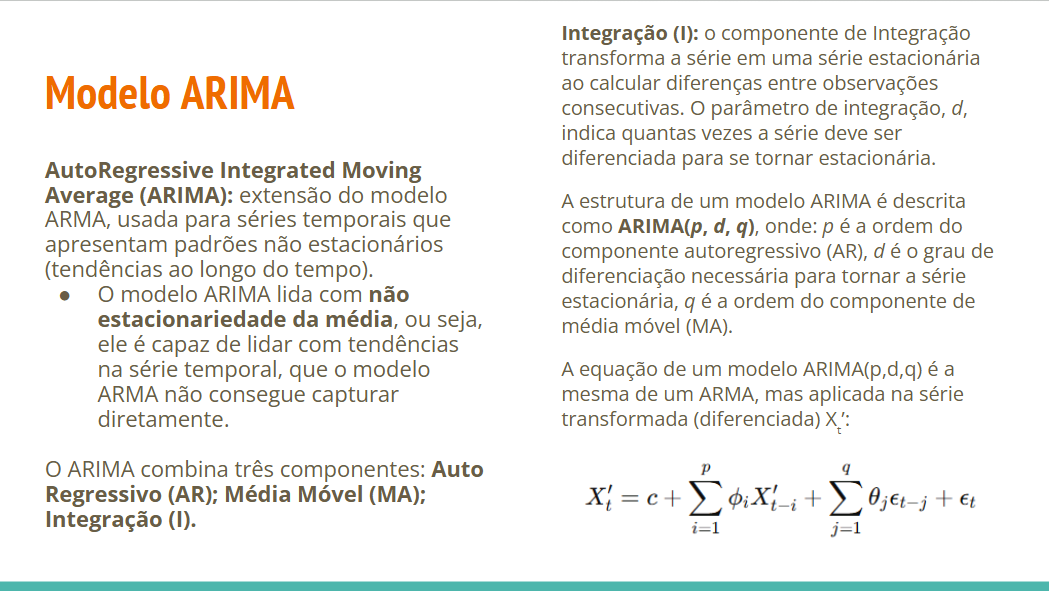

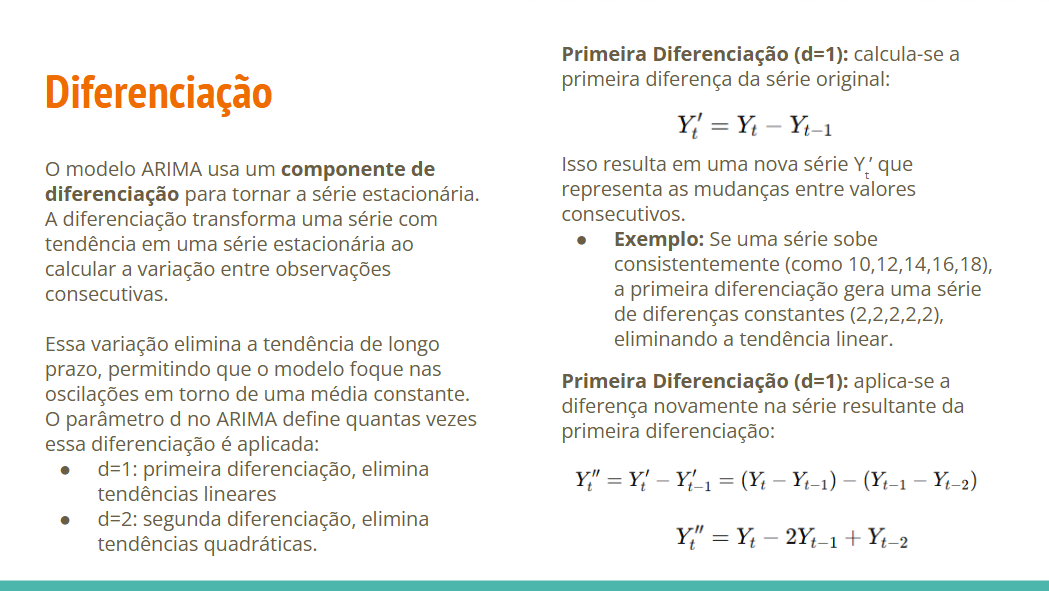

Vamos trabalhar com um modelo ARIMA com apenas uma diferenciação para tendências lineares.

In [ ]:
# Ajustar o modelo ARIMA no conjunto de treino
arima_model = ARIMA(train_df, order=(2, 1, 1))  # Modelo ARIMA com p=2, d=1, q=1
arima_result = arima_model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
# Fazer previsões no conjunto de teste
y_pred_arima = arima_result.forecast(steps=len(test_df))

# Calcular o MSE
mse_arima = mean_squared_error(test_df, y_pred_arima)

print(f'Erro Quadrático Médio do modelo ARIMA: {int(mse_arima)}')

Erro Quadrático Médio do modelo ARIMA: 6290


Text(0.5, 1.0, 'Comparação entre Modelos')

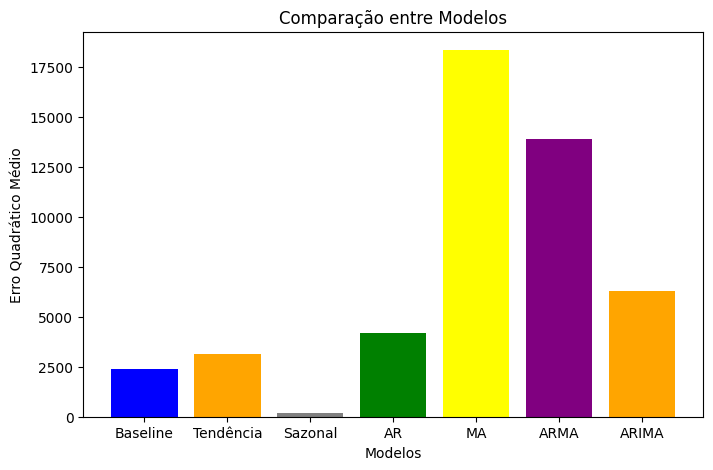

In [ ]:
# Dados para o gráfico
modelos = ['Baseline', 'Tendência', 'Sazonal', 'AR', 'MA', 'ARMA', 'ARIMA']
mse_values = [mse_base, mse_trend, mse_sazonal, mse_ar, mse_ma, mse_arma, mse_arima]

# Plotando o gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(modelos, mse_values, color=['blue', 'orange',  'gray', 'green', 'yellow', 'purple', 'orange'])
plt.xlabel('Modelos')
plt.ylabel('Erro Quadrático Médio')
plt.title('Comparação entre Modelos')

## SARIMA

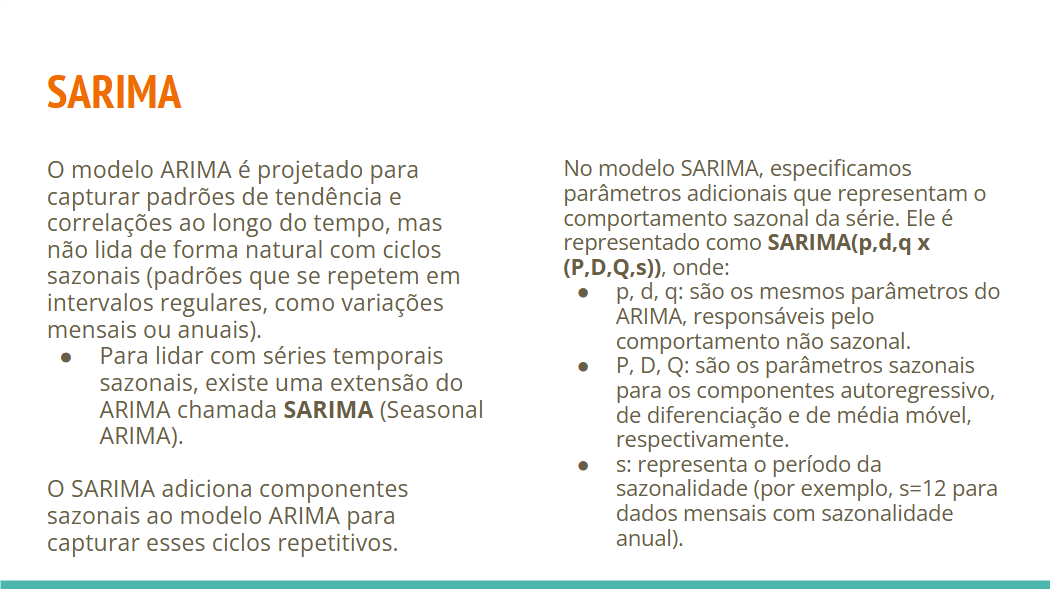

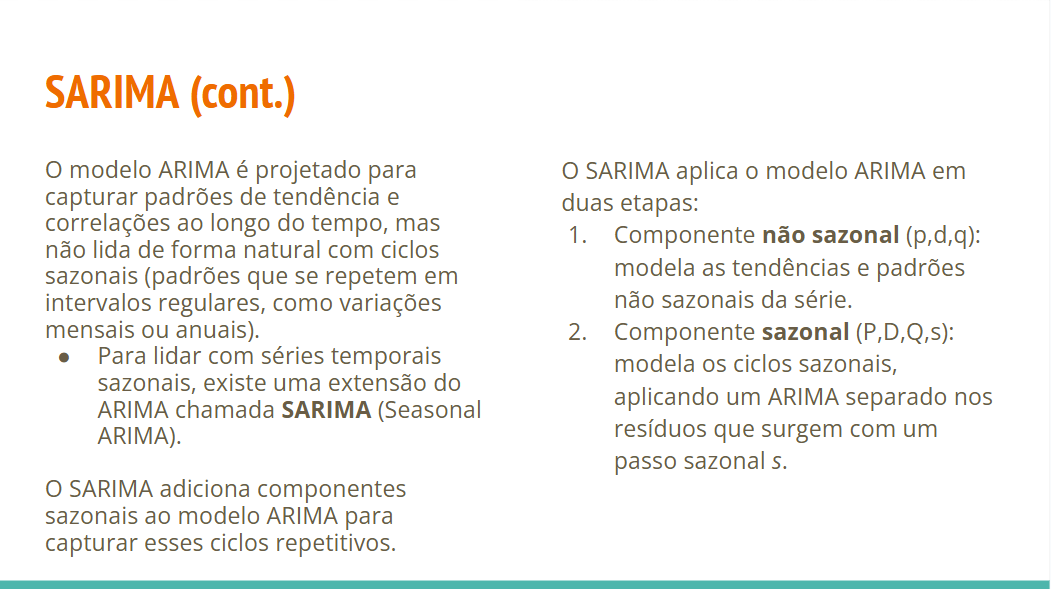

Nossa série parece ter uma sazonalidade clara, que se repete ao longo dos meses. Vamos utilizar o modelo SARIMA para tentar capturar essa regularidade.

In [ ]:
# Ajustar o modelo SARIMA no conjunto de treino
sarima_model = SARIMAX(train_df, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima_model.fit()

# Fazer previsões no conjunto de teste
y_pred_sarima = sarima_result.forecast(steps=len(test_df))

# Calcular o MSE
mse_sarima = mean_squared_error(test_df, y_pred_sarima)

print(f'Erro Quadrático Médio do modelo SARIMA: {int(mse_sarima)}')

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Erro Quadrático Médio do modelo SARIMA: 89


Text(0.5, 1.0, 'Comparação entre Modelos')

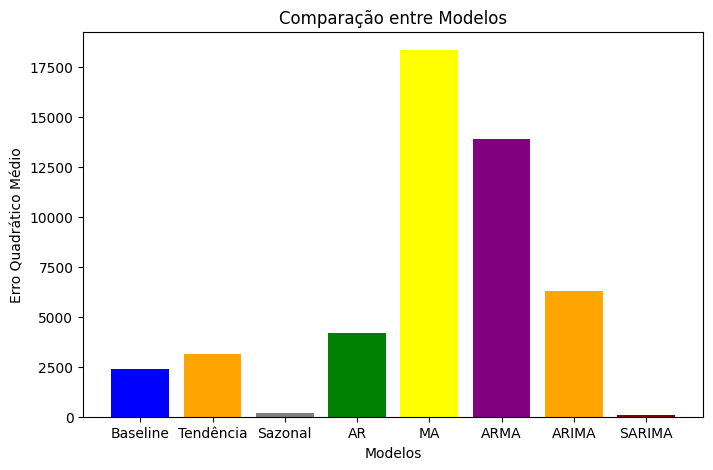

In [ ]:
# Dados para o gráfico
modelos = ['Baseline', 'Tendência', 'Sazonal', 'AR', 'MA', 'ARMA', 'ARIMA', 'SARIMA']
mse_values = [mse_base, mse_trend, mse_sazonal, mse_ar, mse_ma, mse_arma, mse_arima, mse_sarima]

# Plotando o gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(modelos, mse_values, color=['blue', 'orange',  'gray', 'green', 'yellow', 'purple', 'orange', 'maroon'])
plt.xlabel('Modelos')
plt.ylabel('Erro Quadrático Médio')
plt.title('Comparação entre Modelos')

In [ ]:
print('Resultado das previsões:\n')

for model, value in zip(modelos, mse_values):
  print(f'{model}: {int(value)}')

Resultado das previsões:

Baseline: 2379
Tendência: 3153
Sazonal: 175
AR: 4183
MA: 18328
ARMA: 13896
ARIMA: 6290
SARIMA: 89
